# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Isi Nama Kalian | Isi NRP Kalian |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
df = pd.read_csv('../Dataset/bankruptcy.csv')
df.columns = df.columns.str.strip()  # hilangkan spasi di awal/akhir nama kolom

print('Jumlah baris dan kolom:', df.shape)
print('\nTipe data:\n', df.dtypes.value_counts())
print('\nStatistik deskriptif:')
display(df.describe())
print('\nJumlah missing value (total):', df.isnull().sum().sum())
display(df.head())

Jumlah baris dan kolom: (6819, 96)

Tipe data:
 float64    93
int64       3
Name: count, dtype: int64

Statistik deskriptif:


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000



Jumlah missing value (total): 0


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


/tmp/ipykernel_46137/783150266.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Bankrupt?', data=df, palette='Set2', ax=ax)


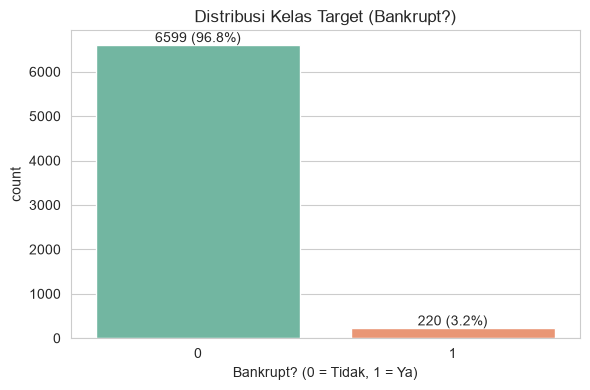

Distribusi kelas:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Dataset TIDAK seimbang (imbalanced): kelas mayoritas ~96.8%, kelas minoritas ~3.2%.


In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='Bankrupt?', data=df, palette='Set2', ax=ax)
ax.set_title('Distribusi Kelas Target (Bankrupt?)')
ax.set_xlabel('Bankrupt? (0 = Tidak, 1 = Ya)')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

print('Distribusi kelas:')
print(df['Bankrupt?'].value_counts())
print('\nDataset TIDAK seimbang (imbalanced): kelas mayoritas ~96.8%, kelas minoritas ~3.2%.')

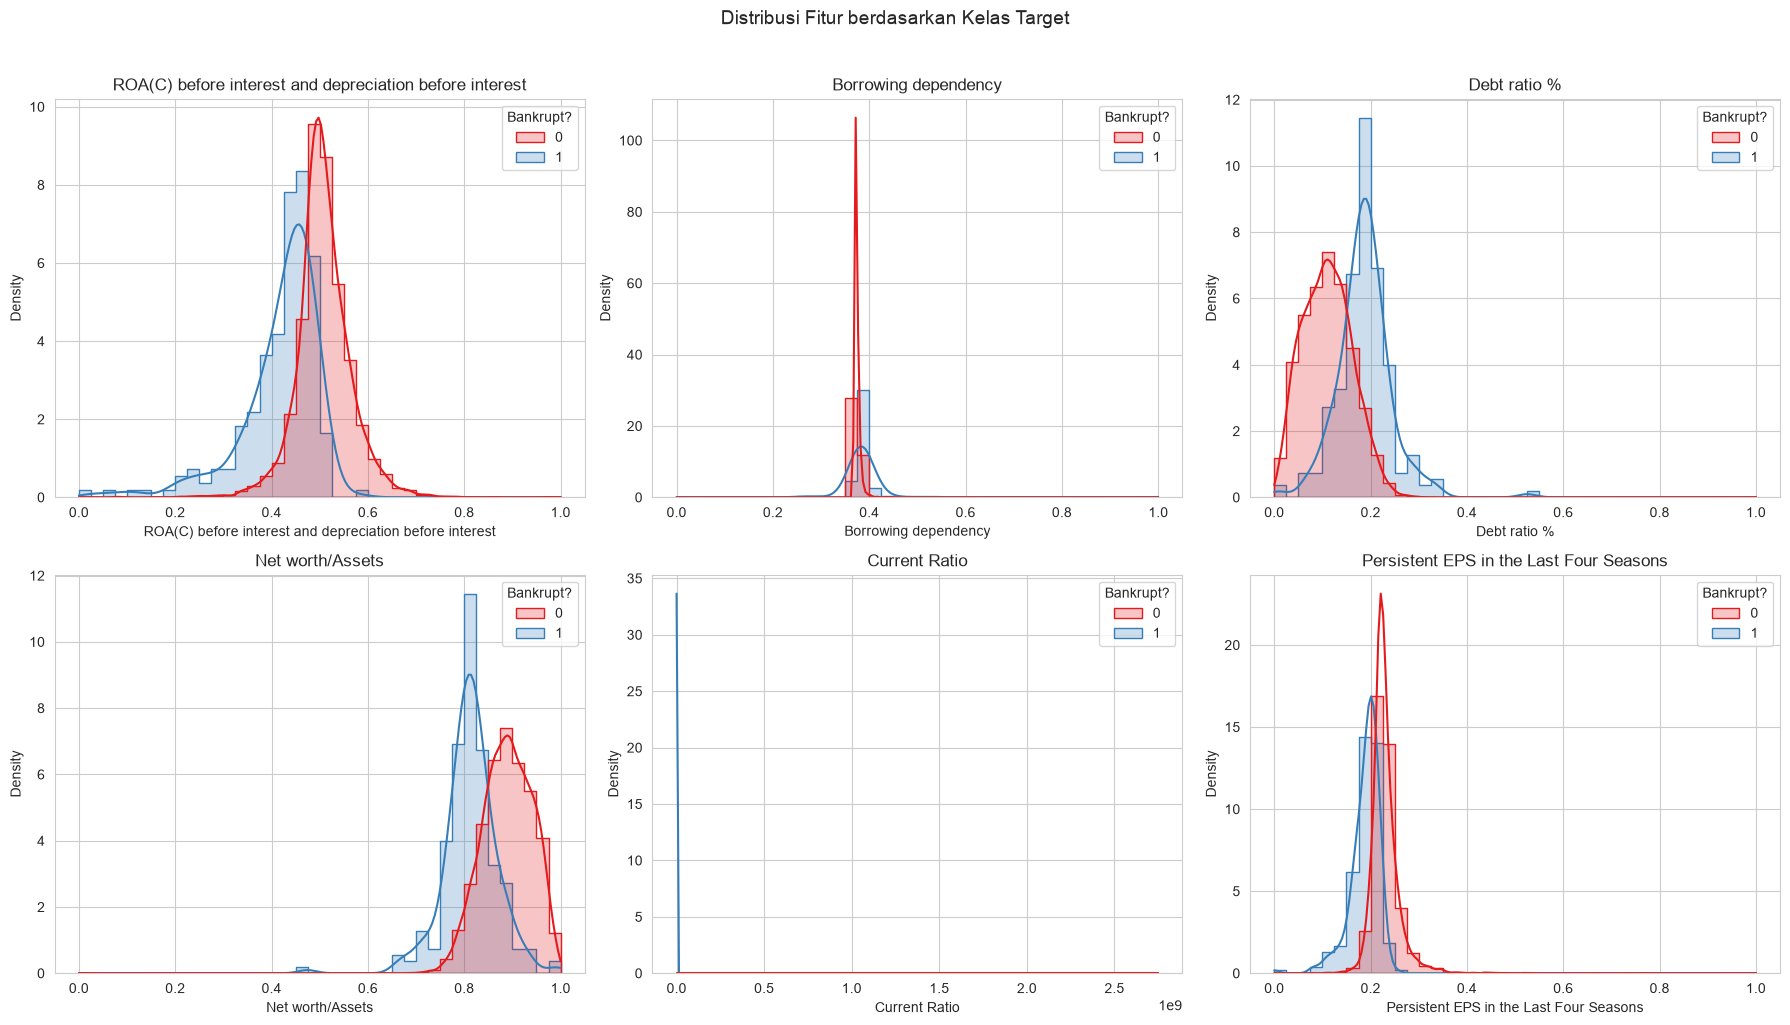

/tmp/ipykernel_46137/2934604223.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Bankrupt?', y=feat, data=df, palette='Set2', ax=ax)
/tmp/ipykernel_46137/2934604223.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Bankrupt?', y=feat, data=df, palette='Set2', ax=ax)
/tmp/ipykernel_46137/2934604223.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Bankrupt?', y=feat, data=df, palette='Set2', ax=ax)


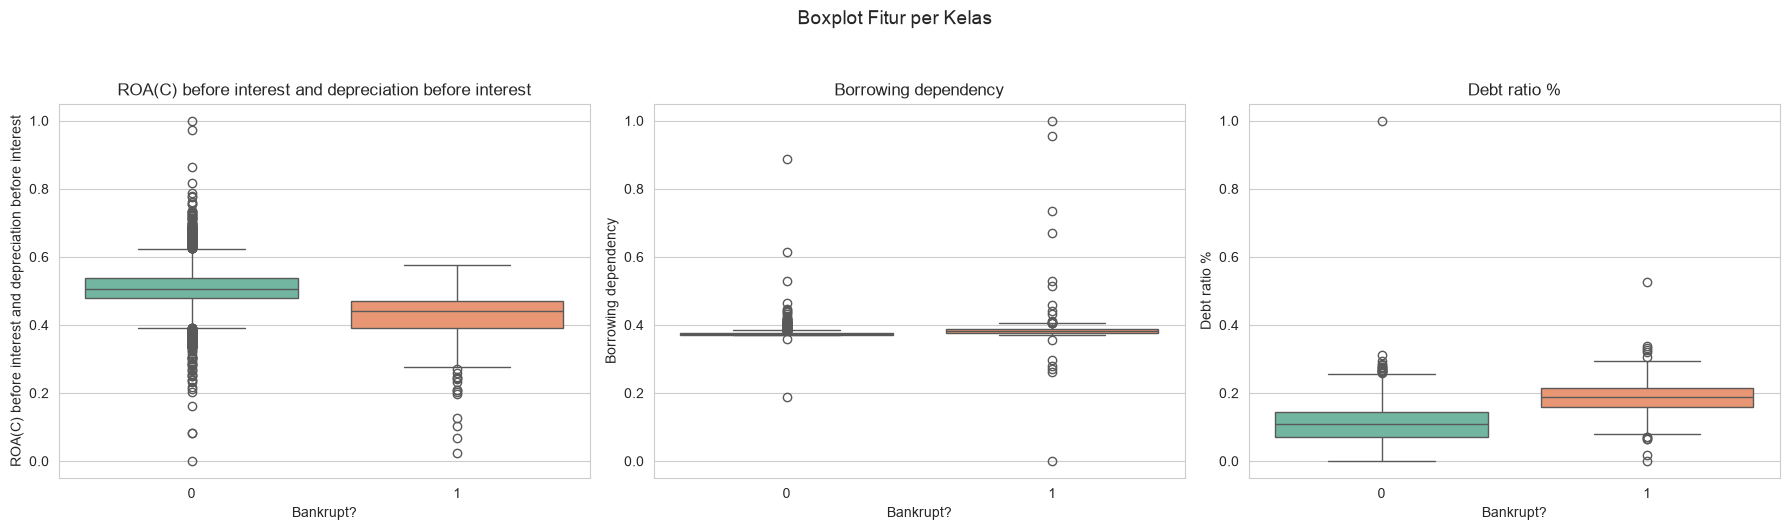

In [4]:
selected_features = ['ROA(C) before interest and depreciation before interest',
                     'Borrowing dependency', 'Debt ratio %',
                     'Net worth/Assets', 'Current Ratio',
                     'Persistent EPS in the Last Four Seasons']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for feat, ax in zip(selected_features, axes.ravel()):
    sns.histplot(data=df, x=feat, hue='Bankrupt?', kde=True, ax=ax, palette='Set1',
                 bins=40, element='step', stat='density', common_norm=False)
    ax.set_title(feat)
plt.suptitle('Distribusi Fitur berdasarkan Kelas Target', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for feat, ax in zip(selected_features[:3], axes):
    sns.boxplot(x='Bankrupt?', y=feat, data=df, palette='Set2', ax=ax)
    ax.set_title(feat)
plt.suptitle('Boxplot Fitur per Kelas', y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

10 fitur dengan korelasi terbesar terhadap target:


Net Income to Total Assets                                -0.315457
ROA(A) before interest and % after tax                    -0.282941
ROA(B) before interest and depreciation after tax         -0.273051
ROA(C) before interest and depreciation before interest   -0.260807
Net worth/Assets                                          -0.250161
Debt ratio %                                               0.250161
Persistent EPS in the Last Four Seasons                   -0.219560
Retained Earnings to Total Assets                         -0.217779
Net profit before tax/Paid-in capital                     -0.207857
Per Share Net profit before tax (Yuan ¥)                  -0.201395
Name: Bankrupt?, dtype: float64

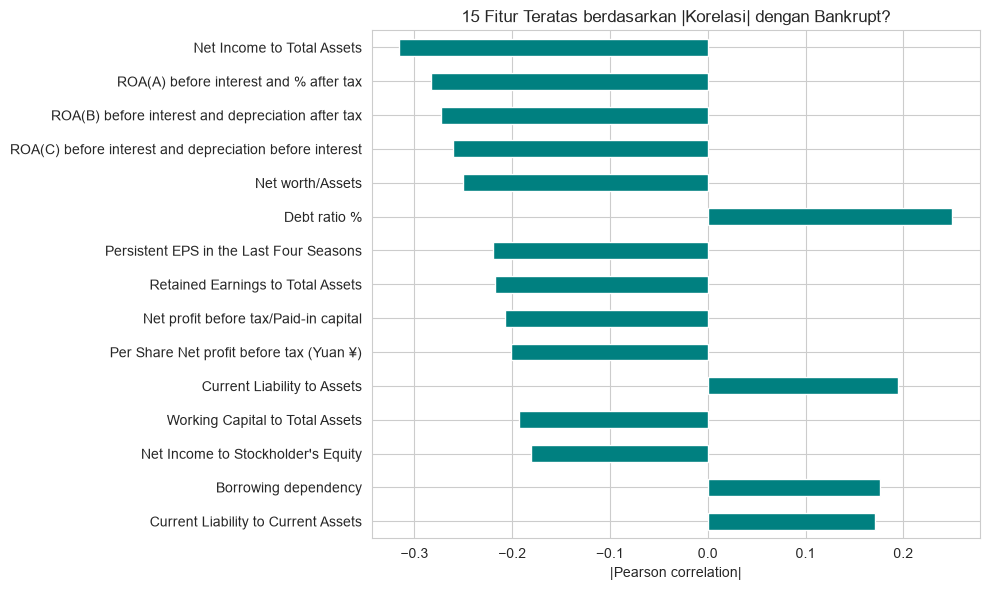

Jumlah baris duplikat: 0
Jumlah fitur konstan (hanya 1 nilai unik): 1


['Net Income Flag']

In [5]:
# EDA tambahan: korelasi fitur terhadap target
corr_with_target = df.corr(numeric_only=True)['Bankrupt?'].drop('Bankrupt?').sort_values(key=abs, ascending=False)
print('10 fitur dengan korelasi terbesar terhadap target:')
display(corr_with_target.head(10))

plt.figure(figsize=(10, 6))
corr_with_target.head(15).plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.title('15 Fitur Teratas berdasarkan |Korelasi| dengan Bankrupt?')
plt.xlabel('|Pearson correlation|')
plt.tight_layout()
plt.show()

# Cek duplikat dan fitur konstan
print('Jumlah baris duplikat:', df.duplicated().sum())
nunique = df.nunique()
print('Jumlah fitur konstan (hanya 1 nilai unik):', (nunique == 1).sum())
display(df.columns[nunique == 1].tolist())

# 2. Preprocessing

In [6]:
# Cek kembali missing value
print('Total missing value:', df.isnull().sum().sum())
display(df.isnull().sum()[df.isnull().sum() > 0])

# Tidak ada missing value pada dataset ini, sehingga tidak diperlukan imputasi.
# Jika ada, strategi tanpa data leakage:
# 1. Hitung nilai imputasi HANYA dari data training (fit pada train, transform ke train & test), ATAU
# 2. Masukkan imputer ke dalam Pipeline sklearn bersama model.
# Dengan begitu informasi dari test set tidak bocor ke training set.

Total missing value: 0


Series([], dtype: int64)

In [7]:
# Cek tipe data: apakah ada fitur kategorikal?
print('Tipe data setiap kolom:')
print(df.dtypes.value_counts())
print('\nFitur bertipe object/kategorikal:', df.select_dtypes(include='object').columns.tolist())

# Seluruh fitur pada dataset ini sudah berupa angka (numerik), sehingga tidak perlu encoding.
# Jika ada fitur kategorikal, pilihan encoding:
# - One-Hot Encoding (pd.get_dummies) untuk fitur nominal tanpa urutan,
# - Ordinal Encoding (OrdinalEncoder) untuk fitur dengan urutan/tier.
# DecisionTreeClassifier scikit-learn hanya menerima input numerik.

Tipe data setiap kolom:
float64    93
int64       3
Name: count, dtype: int64

Fitur bertipe object/kategorikal: []


In [8]:
X = df.drop('Bankrupt?', axis=1)
y = df['Bankrupt?']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Ukuran X_train:', X_train.shape)
print('Ukuran X_test :', X_test.shape)
print('\nDistribusi kelas train:')
display(y_train.value_counts())
print('\nDistribusi kelas test:')
display(y_test.value_counts())

Ukuran X_train: (5455, 95)
Ukuran X_test : (1364, 95)

Distribusi kelas train:


Bankrupt?
0    5279
1     176
Name: count, dtype: int64


Distribusi kelas test:


Bankrupt?
0    1320
1      44
Name: count, dtype: int64

**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [9]:
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)

print('Decision Tree (Gini) berhasil dilatih.')
print('Tinggi pohon  :', dt_gini.get_depth())
print('Jumlah leaf   :', dt_gini.get_n_leaves())

Decision Tree (Gini) berhasil dilatih.
Tinggi pohon  : 20
Jumlah leaf   : 124


In [10]:
y_pred_gini = dt_gini.predict(X_test)
y_pred_gini_train = dt_gini.predict(X_train)

print('Akurasi train (Gini):', accuracy_score(y_train, y_pred_gini_train))
print('Akurasi test  (Gini):', accuracy_score(y_test, y_pred_gini))

Akurasi train (Gini): 1.0
Akurasi test  (Gini): 0.9611436950146628


## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [11]:
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)

print('Decision Tree (Entropy) berhasil dilatih.')
print('Tinggi pohon  :', dt_entropy.get_depth())
print('Jumlah leaf   :', dt_entropy.get_n_leaves())

Decision Tree (Entropy) berhasil dilatih.
Tinggi pohon  : 17
Jumlah leaf   : 99


In [12]:
y_pred_entropy = dt_entropy.predict(X_test)
y_pred_entropy_train = dt_entropy.predict(X_train)

print('Akurasi train (Entropy):', accuracy_score(y_train, y_pred_entropy_train))
print('Akurasi test  (Entropy):', accuracy_score(y_test, y_pred_entropy))

Akurasi train (Entropy): 1.0
Akurasi test  (Entropy): 0.9640762463343109


## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [13]:
# Berdasarkan percobaan sebelumnya, kriteria 'entropy' memberi akurasi test sedikit lebih tinggi,
# sehingga digunakan sebagai kriteria terbaik untuk eksperimen regularisasi ini.
best_criterion = 'entropy'
max_depths = [1, 2, 3, 5, 10, None]

dt_depth_models = {}
for d in max_depths:
    clf = DecisionTreeClassifier(criterion=best_criterion, max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    dt_depth_models[d] = clf
    print(f'max_depth={str(d):>4} -> dilatih (tinggi pohon aktual: {clf.get_depth()})')

max_depth=   1 -> dilatih (tinggi pohon aktual: 1)


max_depth=   2 -> dilatih (tinggi pohon aktual: 2)


max_depth=   3 -> dilatih (tinggi pohon aktual: 3)


max_depth=   5 -> dilatih (tinggi pohon aktual: 5)


max_depth=  10 -> dilatih (tinggi pohon aktual: 10)


max_depth=None -> dilatih (tinggi pohon aktual: 17)


In [14]:
train_accuracies = []
test_accuracies = []
depth_labels = [str(d) for d in max_depths]

for d in max_depths:
    clf = dt_depth_models[d]
    train_accuracies.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, clf.predict(X_test)))

depth_results = pd.DataFrame({
    'max_depth': depth_labels,
    'train_accuracy': train_accuracies,
    'test_accuracy': test_accuracies
})
display(depth_results)

,max_depth,train_accuracy,test_accuracy
0,1,0.967736,0.967742
1,2,0.967736,0.967742
2,3,0.968286,0.969941
3,5,0.974335,0.966276
4,10,0.993034,0.963343
5,None,1.000000,0.964076


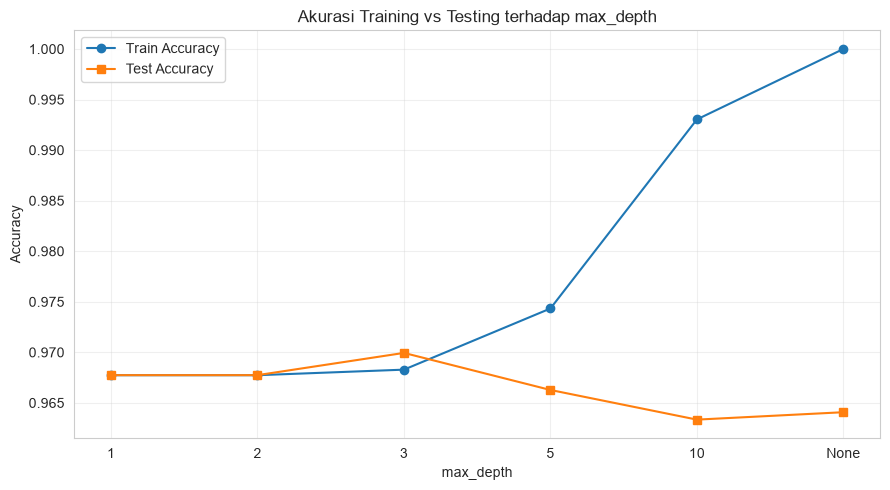

Interpretasi singkat:
- Akurasi training naik terus seiring bertambahnya depth hingga mencapai 1.0 (pohon hafal data train).
- Akurasi testing memuncak di sekitar max_depth=2-3, lalu mulai stagnan/menurun pada depth yang lebih besar.
- Selisih (gap) train-test yang melebar adalah ciri klasik overfitting.


In [15]:
plt.figure(figsize=(9, 5))
plt.plot(depth_labels, train_accuracies, marker='o', label='Train Accuracy')
plt.plot(depth_labels, test_accuracies, marker='s', label='Test Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Akurasi Training vs Testing terhadap max_depth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Interpretasi singkat:')
print('- Akurasi training naik terus seiring bertambahnya depth hingga mencapai 1.0 (pohon hafal data train).')
print('- Akurasi testing memuncak di sekitar max_depth=2-3, lalu mulai stagnan/menurun pada depth yang lebih besar.')
print('- Selisih (gap) train-test yang melebar adalah ciri klasik overfitting.')

# 4. Evaluasi Model

In [16]:
def evaluate(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

eval_df = pd.DataFrame([
    evaluate('Decision Tree (Gini)', y_test, y_pred_gini),
    evaluate('Decision Tree (Entropy)', y_test, y_pred_entropy)
]).set_index('Model')
display(eval_df.round(4))

print('\nClassification Report - Gini:')
print(classification_report(y_test, y_pred_gini, target_names=['Not Bankrupt', 'Bankrupt']))
print('Classification Report - Entropy:')
print(classification_report(y_test, y_pred_entropy, target_names=['Not Bankrupt', 'Bankrupt']))

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree (Gini),0.9611,0.4000,0.4091,0.4045
Decision Tree (Entropy),0.9641,0.4359,0.3864,0.4096



Classification Report - Gini:
              precision    recall  f1-score   support

Not Bankrupt       0.98      0.98      0.98      1320
    Bankrupt       0.40      0.41      0.40        44

    accuracy                           0.96      1364
   macro avg       0.69      0.69      0.69      1364
weighted avg       0.96      0.96      0.96      1364

Classification Report - Entropy:
              precision    recall  f1-score   support

Not Bankrupt       0.98      0.98      0.98      1320
    Bankrupt       0.44      0.39      0.41        44

    accuracy                           0.96      1364
   macro avg       0.71      0.68      0.70      1364
weighted avg       0.96      0.96      0.96      1364



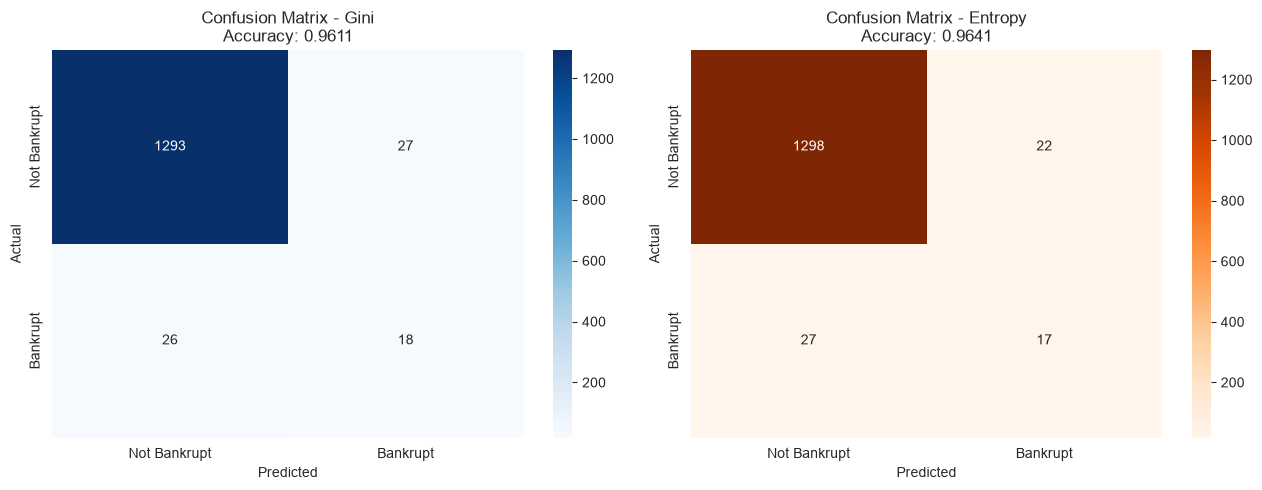

In [17]:
cm_gini = confusion_matrix(y_test, y_pred_gini)
cm_entropy = confusion_matrix(y_test, y_pred_entropy)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm_gini, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Bankrupt', 'Bankrupt'],
            yticklabels=['Not Bankrupt', 'Bankrupt'])
axes[0].set_title(f'Confusion Matrix - Gini\nAccuracy: {accuracy_score(y_test, y_pred_gini):.4f}')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(cm_entropy, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Not Bankrupt', 'Bankrupt'],
            yticklabels=['Not Bankrupt', 'Bankrupt'])
axes[1].set_title(f'Confusion Matrix - Entropy\nAccuracy: {accuracy_score(y_test, y_pred_entropy):.4f}')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

Model terbaik: Decision Tree (Entropy)


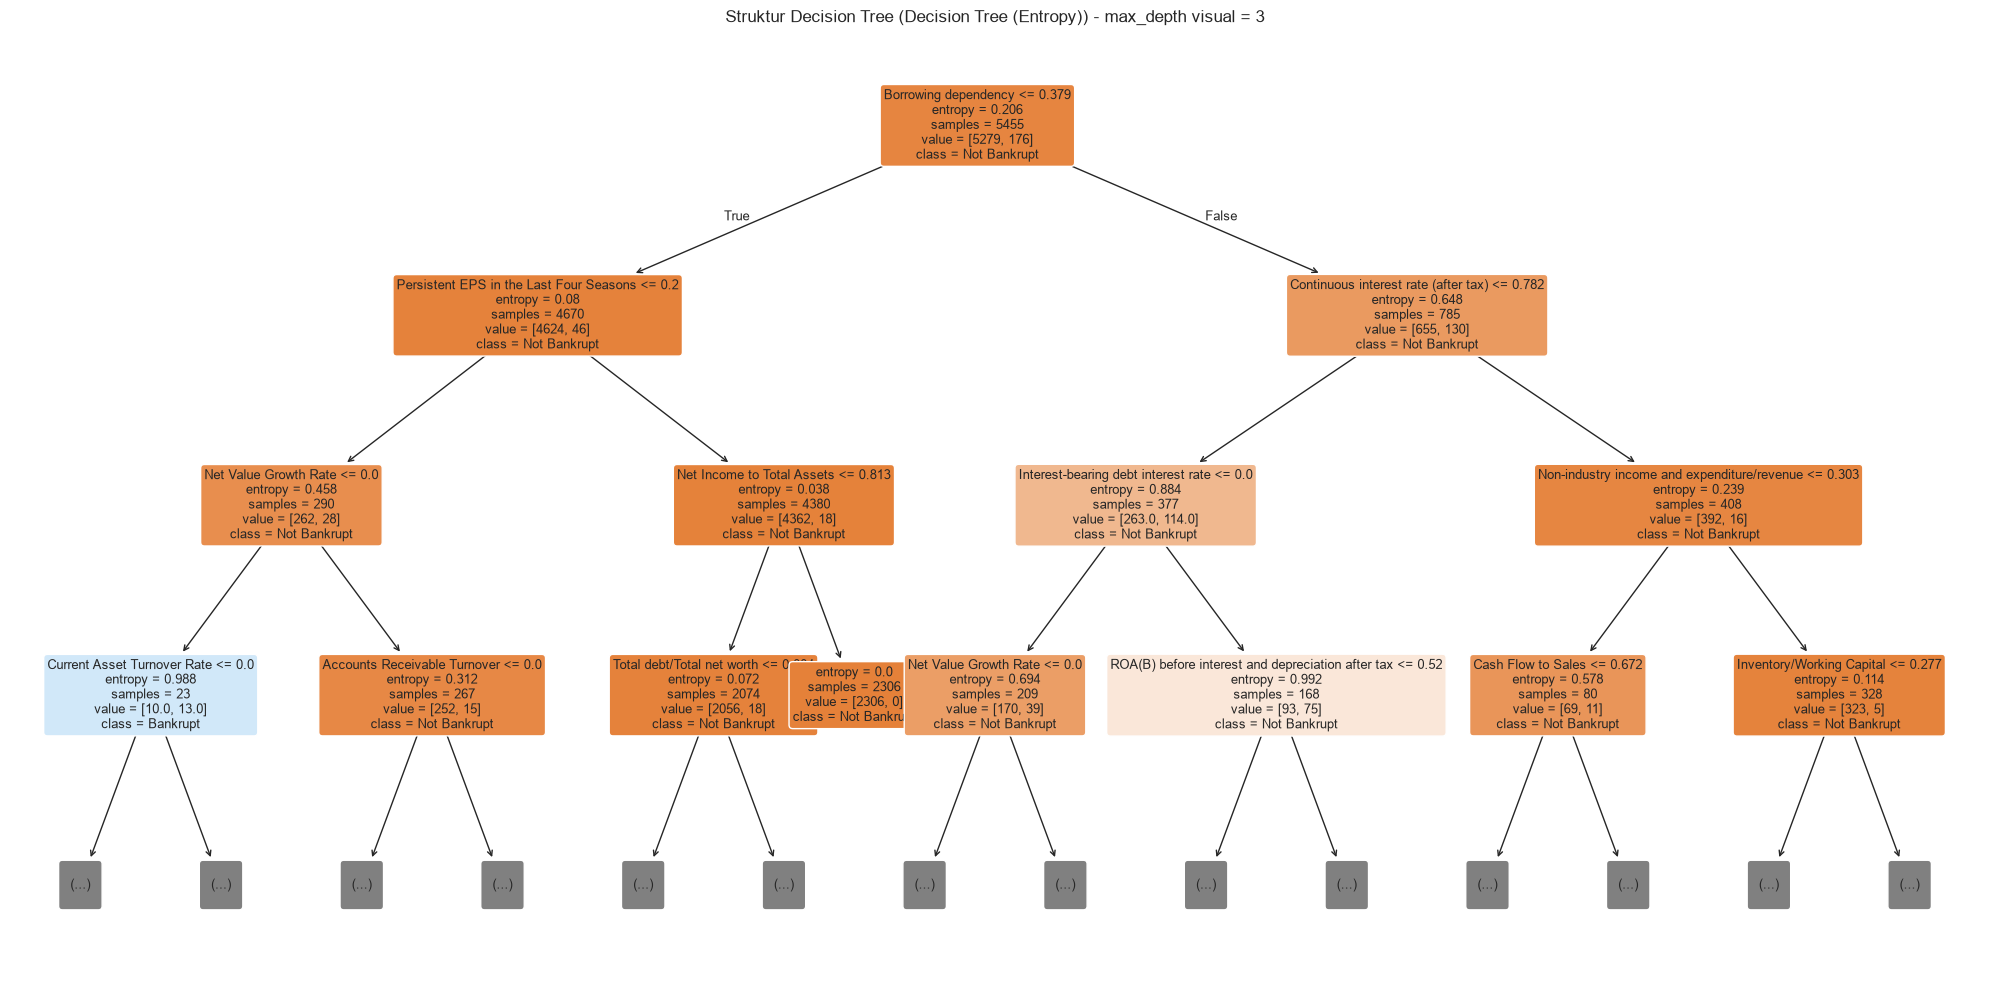

In [18]:
# Model terbaik berdasarkan akurasi test (lihat tabel evaluasi)
best_name = eval_df['Accuracy'].idxmax()
best_model = dt_gini if 'Gini' in best_name else dt_entropy
print('Model terbaik:', best_name)

plt.figure(figsize=(20, 10))
plot_tree(best_model,
          feature_names=X.columns,
          class_names=['Not Bankrupt', 'Bankrupt'],
          filled=True,
          rounded=True,
          max_depth=3,          # batasi kedalaman visualisasi agar mudah dibaca
          fontsize=9)
plt.title(f'Struktur Decision Tree ({best_name}) - max_depth visual = 3')
plt.tight_layout()
plt.show()

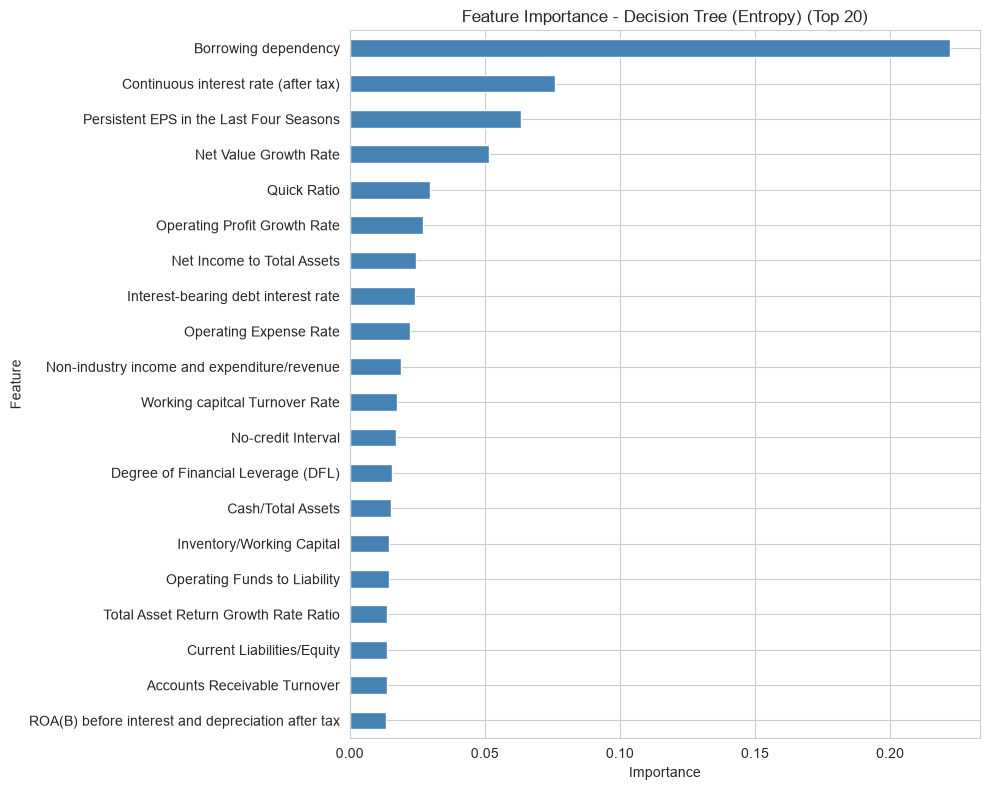

Fitur paling berpengaruh:


Borrowing dependency                           0.222147
Continuous interest rate (after tax)           0.075791
Persistent EPS in the Last Four Seasons        0.063519
Net Value Growth Rate                          0.051659
Quick Ratio                                    0.029765
Operating Profit Growth Rate                   0.026979
Net Income to Total Assets                     0.024663
Interest-bearing debt interest rate            0.024218
Operating Expense Rate                         0.022477
Non-industry income and expenditure/revenue    0.018859
dtype: float64

In [19]:
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances = importances[importances > 0].sort_values()

top_n = min(20, len(importances))
plt.figure(figsize=(10, 8))
importances.tail(top_n).plot(kind='barh', color='steelblue')
plt.title(f'Feature Importance - {best_name} (Top {top_n})')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('Fitur paling berpengaruh:')
display(importances.sort_values(ascending=False).head(10))

# 5. Analisis

### Analisis Hasil Eksperimen

**1. Perbandingan Gini vs Entropy**

Berdasarkan hasil eksperimen pada dataset bankruptcy.csv (6819 sampel, 95 fitur):

| Metrik | Gini | Entropy |
|---|---|---|
| Akurasi train | 1.0000 | 1.0000 |
| Akurasi test | 0.9611 | 0.9641 |
| Precision (kelas Bankrupt) | 0.4000 | 0.4359 |
| Recall (kelas Bankrupt) | 0.4091 | 0.3864 |
| F1-Score (kelas Bankrupt) | 0.4045 | 0.4096 |
| Kedalaman pohon | 20 | 17 |
| Jumlah leaf | 124 | 99 |

Kedua kriteria menghasilkan akurasi train sempurna (1.0) dan akurasi test yang sangat mirip (selisih hanya ~0.3%), sehingga perbedaannya **tidak signifikan**. Entropy sedikit unggul pada akurasi test, precision, dan F1, serta menghasilkan pohon yang lebih kompak (kedalaman 17 vs 20). Hal ini wajar karena Gini dan Entropy adalah ukuran ketidakpastian yang sebenarnya sangat berkorelasi — keduanya memilih split yang pada dasarnya sama, hanya berbeda pada skala pembobotan saat menghitung impurity. Perbedaan nyata biasanya baru terlihat pada kasus multikelas atau fitur dengan banyak kategori.

**2. Temuan eksperimen regularisasi (max_depth)**

Hasil akurasi terhadap max_depth (kriteria entropy):

| max_depth | Train Acc | Test Acc |
|---|---|---|
| 1 | 0.9677 | 0.9677 |
| 2 | 0.9677 | 0.9677 |
| 3 | 0.9683 | 0.9699 |
| 5 | 0.9743 | 0.9663 |
| 10 | 0.9930 | 0.9633 |
| None | 1.0000 | 0.9641 |

- **max_depth = 1–2**: model sederhana; train dan test hampir setara.
- **max_depth = 3**: titik terbaik — akurasi test memuncak di ~0.9699.
- **Mulai max_depth ≥ 5** gejala overfitting terlihat: akurasi train terus naik (0.974 → 0.993 → 1.0), sementara akurasi test justru menurun (0.966 → 0.963). Gap train–test melebar — inilah ciri klasik overfitting pada decision tree.
- Pohon tanpa batas (None) mencapai train accuracy 1.0 tetapi test accuracy hanya ~0.964: pohon terlalu dalam (kedalaman 17) sehingga menghafal noise pada data training.

**3. Fitur paling berpengaruh (feature importance)**

Berdasarkan model terbaik (Entropy), fitur dengan importance tertinggi adalah:
1. Borrowing dependency (~0.22)
2. Continuous interest rate (after tax) (~0.08)
3. Persistent EPS in the Last Four Seasons (~0.06)
4. Net Value Growth Rate (~0.05)
5. Quick Ratio, Operating Profit Growth Rate, Net Income to Total Assets, dst.

Secara finansial masuk akal: ketergantungan pinjaman (borrowing dependency) yang tinggi dan pendapatan persisten yang lemah adalah indikator kuat perusahaan menuju kebangkrutan.

**4. Catatan tentang imbalance data**

Dataset sangat imbalanced (3.2% kelas positif). Akurasi ~96% hampir sama dengan akurasi prediksi "selalu tidak bangkrut", sehingga **accuracy bukan metrik yang cukup**. Precision/Recall/F1 pada kelas Bankrupt jauh lebih rendah (~0.4) dan menunjukkan model masih banyak melewatkan kasus bangkrut. Confusion matrix menunjukkan sebagian besar kasus Bankrupt di test set (44 sampel) terlewat oleh model.

# 6. Kesimpulan dan Saran

### Kesimpulan

1. **Gini vs Entropy**: Pada dataset ini kedua kriteria memberikan hasil yang sangat mirip (selisih akurasi test < 0.5%). Entropy sedikit lebih baik pada akurasi test dan F1, serta menghasilkan pohon yang lebih kecil. Kesimpulannya, pemilihan kriteria split bukan faktor penentu utama performa pada kasus biner sederhana seperti ini.

2. **Overfitting dan max_depth**: Model tanpa batas kedalaman mengalami overfitting — train accuracy 1.0 tetapi test accuracy turun. Gejala overfitting mulai tampak pada **max_depth ≥ 5**, dengan titik optimal di **max_depth = 3** (test accuracy tertinggi ~0.9699). Regularisasi melalui max_depth efektif membatasi pertumbuhan pohon dan menjaga generalisasi.

3. **Fitur dominan**: Borrowing dependency, Continuous interest rate (after tax), Persistent EPS in the Last Four Seasons, dan Net Value Growth Rate adalah fitur paling berpengaruh, sesuai intuisi finansial tentang kriteria kebangkrutan.

4. **Keterbatasan**: Karena data sangat imbalanced, metrik accuracy menyesatkan; recall pada kelas bangkrut masih rendah sehingga banyak kasus positif yang terlewat.

### Saran

- Gunakan **class_weight='balanced'** atau teknik resampling (SMOTE) pada data training untuk menaikkan recall kelas minoritas.
- Lakukan **cost-complexity pruning (ccp_alpha)** untuk membandingkan dengan batasan max_depth.
- Coba hyperparameter lain: `min_samples_leaf`, `min_samples_split`, `max_features`.
- Gunakan **GridSearchCV/StratifiedKFold** untuk pencarian hyperparameter yang lebih valid.
- Bandingkan dengan model lain (Random Forest, Gradient Boosting, Logistic Regression dengan class weight) sebagai baseline.
- Evaluasi dengan **F1, ROC-AUC, atau PR-AUC**, bukan hanya accuracy.